# DS 5003, SP 2026 - Healthcare Data Science 

## *For Professor Christian Wernz, PhD, University of Virginia*

---

#### Team Members
* **Robert Ashby** | *University of Virginia, School of Data Science*  gsr3qz@virginia.edu
* **Xavier Colbert** | *University of Virginia, School of Data Science*  kxp3jj@virginia.edu
* **Alysa Pugmire** | *University of Virginia, School of Data Science*  amp3xs@virginia.edu
* **Jasmine Waller** | *University of Virginia, School of Data Science*  vwx5pn@virginia.edu

# CMS HAI Risk Prediction Pipeline
**Objective:** Develop a tool to determine if a facility is at risk of an HAI incident (HAI_1 through HAI_6) and identify which facility measures contribute most to correcting an "at-risk" status.

In [8]:
import sys
import numpy as np
import importlib
from pathlib import Path

RANDOM_SEED = 42
# Set for numpy, pandas, and sklearn
np.random.seed(RANDOM_SEED)

# Add the 'code' folder to the system path so Python can find your scripts
if './code' not in sys.path:
    sys.path.append('./code')

print("Pipeline initialized. Ready to execute modules.")

Pipeline initialized. Ready to execute modules.


## 0. Data Retrieval
Self-healing check: Fetches CMS ZIP if data/raw is empty.

In [9]:
step_00 = importlib.import_module("00_download_data")
step_00.download_and_extract_cms_data()

[SKIP] Data already exists in D:\Documents\School\UVA\MSDS\DS 5003\Project\GitHub\cms-hai-risk-prediction\data\raw\cms_hospitals_jan2026


True

## 1. Data Import
Dynamically sweep the `data/raw/` directory and ingest ALL available CMS datasets.

In [10]:
# Import the module dynamically
step_01 = importlib.import_module("01_data_import")

# Execute the extraction function
raw_datasets = step_01.load_all_raw_data()

Scanning directory: D:\Documents\School\UVA\MSDS\DS 5003\Project\GitHub\cms-hai-risk-prediction\data\raw\cms_hospitals_jan2026
--------------------------------------------------
Found 73 CSV files. Beginning import...

[LOADED] ASCQR_OAS_CAHPS_BY_ASC                   | Rows: 4452    | Cols: 30
[LOADED] ASCQR_OAS_CAHPS_NATIONAL                 | Rows: 1       | Cols: 21
[LOADED] ASCQR_OAS_CAHPS_STATE                    | Rows: 56      | Cols: 22
[LOADED] ASC_Facility                             | Rows: 5711    | Cols: 47
[LOADED] ASC_National                             | Rows: 1       | Cols: 37
[LOADED] ASC_State                                | Rows: 54      | Cols: 34
[LOADED] Birthing_Friendly_Hospitals_Geocoded     | Rows: 2265    | Cols: 7
[LOADED] CJR_Quality_Reporting_January_2026_Produ | Rows: 320     | Cols: 18
[LOADED] CMS_PSI_6_decimal_file                   | Rows: 52327   | Cols: 13
[LOADED] Complications_and_Deaths-Hospital        | Rows: 95780   | Cols: 18
[LOADED] Com

## 2. Data Interpretation
Profile all ingested raw datasets to evaluate row counts, memory usage, and the presence of joining keys (Facility ID). This generates the dataset inventory report.

In [11]:
# Import the module dynamically
step_02 = importlib.import_module("02_data_interpretation")

# Generate the profile and output the CSV to the interim folder
if raw_datasets:
    data_profile = step_02.generate_data_profile(raw_datasets)
    display(data_profile.head(10)) # Preview the top 10 largest files
else:
    print("No data available to profile.")


Analyzing datasets...

[SUCCESS] Data interpretation profile saved to: D:\Documents\School\UVA\MSDS\DS 5003\Project\GitHub\cms-hai-risk-prediction\data\interim\dataset_inventory_profile.csv
Review this CSV to determine which files to cull in Step 03.


,Dataset_Name,Row_Count,Column_Count,Has_Facility_ID,Memory_MB,Columns_List
20,HCAHPS-Hospital,325652,22,True,396.10,"Facility ID, Facility Name, Address, City/Town..."
23,Healthcare_Associated_Infections-Hospital,172404,15,True,145.91,"Facility ID, Facility Name, Address, City/Town..."
64,Timely_and_Effective_Care-Hospital,138129,16,True,126.30,"Facility ID, Facility Name, Address, City/Town..."
9,Complications_and_Deaths-Hospital,95780,18,True,95.69,"Facility ID, Facility Name, Address, City/Town..."
42,OQR_OAS_CAHPS_BY_HOSPITAL,92500,20,True,102.17,"Facility ID, Facility Name, Address, City/Town..."
67,Unplanned_Hospital_Visits-Hospital,67046,20,True,75.94,"Facility ID, Facility Name, Address, City/Town..."
38,Medicare_Hospital_Spending_by_Claim,63646,13,True,36.34,"Facility Name, Facility ID, State, Period, Cla..."
8,CMS_PSI_6_decimal_file,52327,13,True,35.20,"Facility ID, Facility Name, Address, City/Town..."
45,Outpatient_Imaging_Efficiency-Hospital,18500,14,True,13.33,"Facility ID, Facility Name, Address, City/Town..."
19,FY_2026_Hospital_Readmissions_Reduction_Progra...,18330,12,True,7.16,"Facility Name, Facility ID, State, Measure Nam..."


## 3. Data Processing & Ground Truth
Defines HAI_at_risk (1/0) based on all 6 primary HAI measures.

In [12]:
step_03 = importlib.import_module("03_data_processing")

if 'raw_datasets' in locals():
    master_data = step_03.build_target_and_master(raw_datasets)
    display(master_data.head())

[SUCCESS] Master Data Created. At Risk Count: 196


,Facility ID,HAI_at_risk,Hospital Type,Hospital Ownership,Hospital overall rating
0,010001,0,Acute Care Hospitals,Government - Hospital District or Authority,4
1,010005,0,Acute Care Hospitals,Government - Hospital District or Authority,3
2,010006,0,Acute Care Hospitals,Proprietary,2
3,010007,0,Acute Care Hospitals,Voluntary non-profit - Private,1
4,010008,0,Acute Care Hospitals,Proprietary,Not Available


## 4. Exploratory Data Analysis
Visualizing the risk distribution across the dataset.

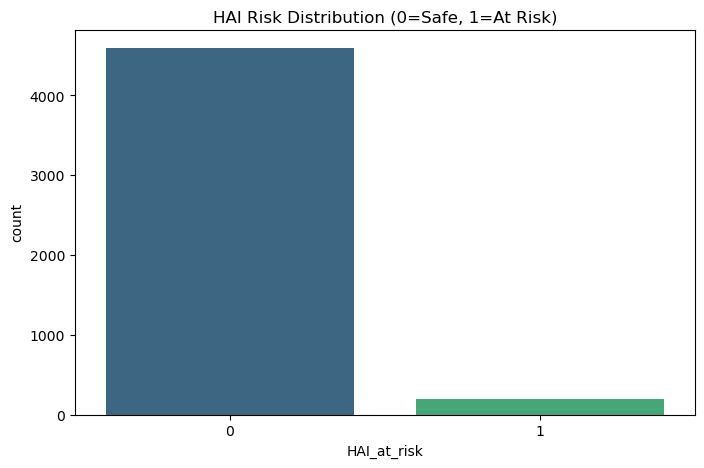

In [13]:
step_04 = importlib.import_module("04_data_analysis")

if 'master_data' in locals():
    step_04.run_eda()

## 5. Automated Feature Mining
Crawls all 73 datasets to extract, pivot, and merge numeric features into a wide modeling format.

In [14]:
step_05 = importlib.import_module("05_feature_identification")

if 'raw_datasets' in locals():
    # We pass the raw_datasets dictionary we loaded in Step 01
    final_df = step_05.mine_features(raw_datasets)
    display(final_df.head())

Beginning Feature Mining across 73 datasets...
[MINED] Complications_and_Deaths-Hospital: Added 16 features.
[MINED] Healthcare_Associated_Infections-Hospital: Added 23 features.
[SKIP] HOSPITAL_QUARTERLY_MSPB_6_DECIMALS failed to pivot: You are trying to merge on str and int64 columns for key 'Facility ID'. If you wish to proceed you should use pd.concat
[SKIP] Medicare_Hospital_Spending_Per_Patient-Hospital failed to pivot: You are trying to merge on str and int64 columns for key 'Facility ID'. If you wish to proceed you should use pd.concat
[SKIP] Outpatient_Imaging_Efficiency-Hospital failed to pivot: You are trying to merge on str and int64 columns for key 'Facility ID'. If you wish to proceed you should use pd.concat
[SKIP] PATIENT_REPORTED_OUTCOMES_FACILITY failed to pivot: You are trying to merge on str and int64 columns for key 'Facility ID'. If you wish to proceed you should use pd.concat
[SKIP] PCH_HEALTHCARE_ASSOCIATED_INFECTIONS_HOSPITAL failed to pivot: You are trying to 

,Facility ID,HAI_at_risk,Hospital Type,Hospital Ownership,Hospital overall rating,Hybrid_HWM,MORT_30_COPD,MORT_30_HF,MORT_30_PN,MORT_30_STK,...,SUB_2,SUB_3,TOB_3,IMM-3,OP-22,OP-29,SEP-1,STK-02,VTE-1,VTE-2
0,010001,0,Acute Care Hospitals,Government - Hospital District or Authority,4,4.5,9.4,10.2,18.4,13.5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,010005,0,Acute Care Hospitals,Government - Hospital District or Authority,3,4.6,8.9,14.1,21.2,12.9,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,010006,0,Acute Care Hospitals,Proprietary,2,5.2,8.7,12.5,19.6,12.4,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,010007,0,Acute Care Hospitals,Voluntary non-profit - Private,1,4.8,11.2,13.4,25.4,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,010008,0,Acute Care Hospitals,Proprietary,Not Available,4.3,NaN,NaN,15.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 6. Log Regression
Blurb

In [ ]:
# run 06 .py log regression and save model

## 7. Rand Forst

In [ ]:
# 07

# Meeting Discussion 3/13/26

**Which Metrics to Use**

- Not accuracy because of the class imbalance
- ROC-AUC, Precision-Recall curve, Weighted and macro F1 score, Matthews Correlation Coefficient, confusion

**Reproducibility and Splits**

- Put this in the ipynb 
- tonight's score as random seed
- StandardScaler

**Cross-Validation**
- 5 fold CV with stratified sampling and shuffling
- tune hyperparameters and threshold

**Class Imbalance**
- Class weights, smote with additional guardrails

**Data Cleaning**
- Punt handling string variable and missing data until we decide which features we want to include
- May go back to our original data set